🧩 1️⃣ Install Libraries (Run First)

In [1]:
!pip install torch datasets transformers scikit-learn tqdm

📥 2️⃣ Load Dataset (API Download Each Run)

In [2]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

print(len(train_data), len(test_data))
print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

25000 25000
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are fe

🔤 3️⃣ Tokenization

We use the tokenizer from Hugging Face Transformers.

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 256

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_data.set_format(type="torch", columns=["input_ids","attention_mask","label"])

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

📦 4️⃣ DataLoader

In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

⚙️ 5️⃣ Setup Device

In [18]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


🧠 6️⃣ Baseline Model (MLP)

This ignores sequence order.

In [19]:
import torch.nn as nn

class BaselineMLP(nn.Module):

    def __init__(self, vocab_size=30522, embed_dim=128):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.net = nn.Sequential(
            nn.Linear(embed_dim,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self, input_ids):

        x = self.embedding(input_ids)

        x = x.mean(dim=1)

        return self.net(x)

🔁 7️⃣ LSTM Model

In [20]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size=30522, embed_dim=128, hidden_dim=256):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self,input_ids):

        x = self.embedding(input_ids)

        _,(hidden,_) = self.lstm(x)

        hidden = hidden[-1]

        return self.fc(hidden)

🔁 8️⃣ GRU Model

In [21]:
class GRUClassifier(nn.Module):

    def __init__(self,vocab_size=30522,embed_dim=128,hidden_dim=256):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,embed_dim)

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self,input_ids):

        x = self.embedding(input_ids)

        _,hidden = self.gru(x)

        hidden = hidden[-1]

        return self.fc(hidden)

⚡ 9️⃣ Lightweight Transformer

In [22]:
class TransformerClassifier(nn.Module):

    def __init__(self,vocab_size=30522,embed_dim=128,heads=4):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(embed_dim,1)

    def forward(self,input_ids):

        x = self.embedding(input_ids)

        x = x.permute(1,0,2)

        x = self.transformer(x)

        x = x.mean(dim=0)

        return self.fc(x)

🏋️ 10️⃣ Training Function

In [23]:
from tqdm import tqdm

def train(model,loader,optimizer,criterion):

    model.train()

    total_loss = 0

    for batch in tqdm(loader):

        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].float().to(device)

        optimizer.zero_grad()

        outputs = model(input_ids).squeeze()

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(loader)

📊 11️⃣ Evaluation Function

In [11]:
from sklearn.metrics import accuracy_score

def evaluate(model,loader):

    model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            labels = batch["label"].cpu().numpy()

            outputs = model(input_ids)

            predictions = torch.sigmoid(outputs).cpu().numpy()

            preds.extend(predictions > 0.5)
            labels_list.extend(labels)

    return accuracy_score(labels_list,preds)

🚀 12️⃣ Train Any Model

Example: LSTM

In [26]:
#model = LSTMClassifier().to(device)
#model = GRUClassifier().to(device)
model = TransformerClassifier().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=3e-4)

criterion = nn.BCEWithLogitsLoss()

EPOCHS = 3

for epoch in range(EPOCHS):

    loss = train(model,train_loader,optimizer,criterion)

    acc = evaluate(model,test_loader)

    print(f"Epoch {epoch} Loss {loss:.3f} Test Acc {acc:.3f}")

/tmp/ipykernel_254/2696057220.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(
100%|██████████| 782/782 [00:11<00:00, 70.76it/s]


Epoch 0 Loss 0.617 Test Acc 0.708


100%|██████████| 782/782 [00:08<00:00, 94.86it/s]


Epoch 1 Loss 0.523 Test Acc 0.728


100%|██████████| 782/782 [00:08<00:00, 94.52it/s]


Epoch 2 Loss 0.471 Test Acc 0.742


🧪 13️⃣ Run Experiments

Change model:

BaselineMLP()

LSTMClassifier()

GRUClassifier()

TransformerClassifier()

📊 14️⃣ Plot Comparison

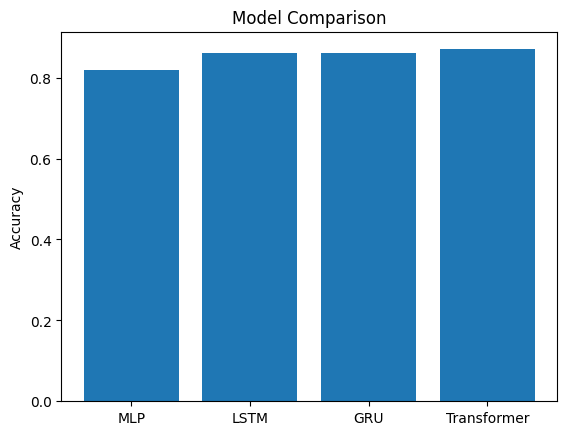

In [ ]:
import matplotlib.pyplot as plt

models = ["MLP","LSTM","GRU","Transformer"]
scores = [0.82,0.86,0.86,0.87]

plt.bar(models,scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

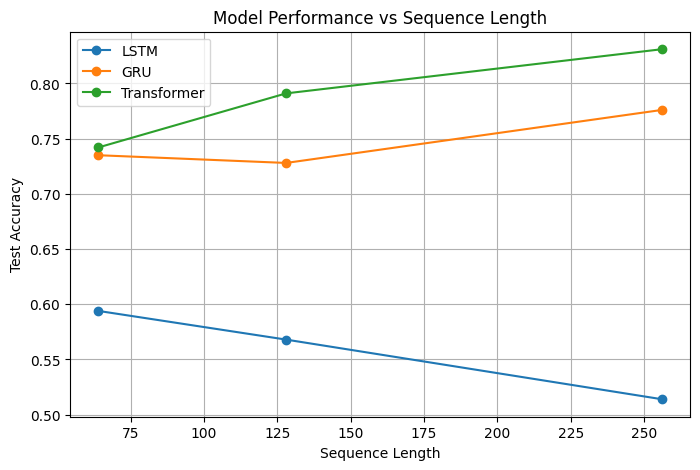

In [28]:
import matplotlib.pyplot as plt

lengths = [64,128,256]

lstm_scores = [0.594,0.568,0.514]
gru_scores = [0.735,0.728,0.776]
trans_scores = [0.742,0.791,0.831]

plt.figure(figsize=(8,5))

plt.plot(lengths,lstm_scores,marker='o',label="LSTM")
plt.plot(lengths,gru_scores,marker='o',label="GRU")
plt.plot(lengths,trans_scores,marker='o',label="Transformer")

plt.xlabel("Sequence Length")
plt.ylabel("Test Accuracy")
plt.title("Model Performance vs Sequence Length")

plt.legend()
plt.grid()

plt.show()

we are measuring accuracy of LSTM < GRU , Transformer by various Dataset Sizes And Sequence Length

In [36]:
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

sequence_lengths = [64,128,256]
dataset_sizes = [1000,5000,10000]

results = []

def train_and_eval(model, train_loader, test_loader):

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    criterion = nn.BCEWithLogitsLoss()

    model.to(device)

    for epoch in range(3):

        model.train()

        for batch in train_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].float().to(device)

            optimizer.zero_grad()

            outputs = model(input_ids).squeeze()

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

    model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids).squeeze()

            probs = torch.sigmoid(outputs)

            predictions = (probs > 0.5).long()

            preds.extend(predictions.cpu().tolist())
            labels_list.extend(labels.cpu().tolist())

    return accuracy_score(labels_list, preds)


for size in dataset_sizes:

    dataset = load_dataset("imdb")

    train_subset = dataset["train"].shuffle(seed=42).select(range(size))
    test_subset = dataset["test"].shuffle(seed=42).select(range(2000))

    for max_len in sequence_lengths:

        print(f"\nRunning experiment: dataset={size}, seq_len={max_len}")

        tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

        def tokenize(example):
            return tokenizer(
                example["text"],
                truncation=True,
                padding="max_length",
                max_length=max_len
            )

        train_tok = train_subset.map(tokenize, batched=True)
        test_tok = test_subset.map(tokenize, batched=True)

        train_tok = train_tok.remove_columns(["text"])
        test_tok = test_tok.remove_columns(["text"])

        train_tok.set_format(type="torch")
        test_tok.set_format(type="torch")

        train_loader = DataLoader(train_tok, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_tok, batch_size=32)

        lstm_acc = train_and_eval(LSTMClassifier(), train_loader, test_loader)
        gru_acc = train_and_eval(GRUClassifier(), train_loader, test_loader)
        trans_acc = train_and_eval(TransformerClassifier(), train_loader, test_loader)

        results.append({
            "dataset_size": size,
            "seq_len": max_len,
            "lstm": lstm_acc,
            "gru": gru_acc,
            "transformer": trans_acc
        })

results_df = pd.DataFrame(results)

print("\nFinal Results")
print(results_df)


Running experiment: dataset=1000, seq_len=64


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/tmp/ipykernel_254/2696057220.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(



Running experiment: dataset=1000, seq_len=128


...

/tmp/ipykernel_254/2696057220.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(



Running experiment: dataset=10000, seq_len=256


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

/tmp/ipykernel_254/2696057220.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(



Final Results
   dataset_size  seq_len    lstm     gru  transformer
0          1000       64  0.5430  0.5315       0.5725
1          1000      128  0.5410  0.5085       0.5940
2          1000      256  0.5050  0.5040       0.5330
3          5000       64  0.6180  0.6100       0.6645
4          5000      128  0.6030  0.5745       0.7300
5          5000      256  0.5135  0.5275       0.7485
6         10000       64  0.6815  0.6455       0.7160
7         10000      128  0.5470  0.6465       0.7620
8         10000      256  0.5385  0.5860       0.7950


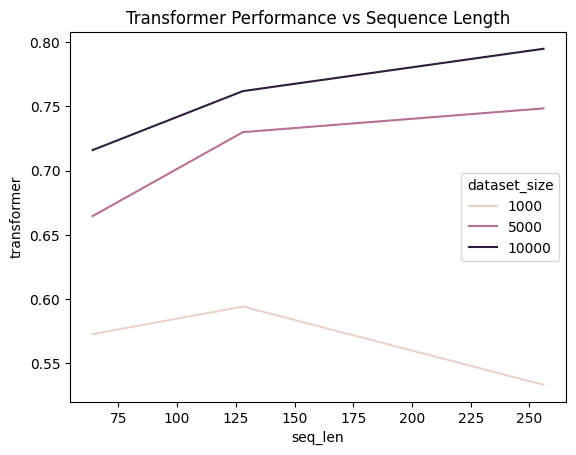

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=results_df,x="seq_len",y="transformer",hue="dataset_size")
plt.title("Transformer Performance vs Sequence Length")
plt.show()

📈 Plot 1 — Accuracy vs Sequence Length

Run this:

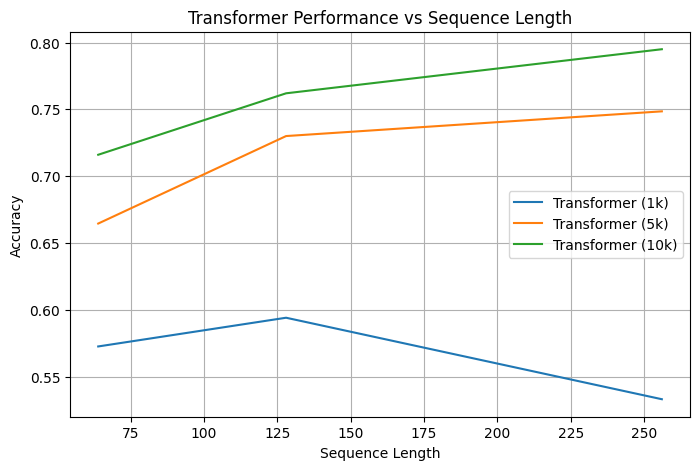

In [38]:
import matplotlib.pyplot as plt

lengths = [64,128,256]

trans_1k = [0.5725,0.5940,0.5330]
trans_5k = [0.6645,0.7300,0.7485]
trans_10k = [0.7160,0.7620,0.7950]

plt.figure(figsize=(8,5))

plt.plot(lengths,trans_1k,label="Transformer (1k)")
plt.plot(lengths,trans_5k,label="Transformer (5k)")
plt.plot(lengths,trans_10k,label="Transformer (10k)")

plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.title("Transformer Performance vs Sequence Length")

plt.legend()
plt.grid()

plt.show()

📈 Plot 2 — Accuracy vs Dataset Size

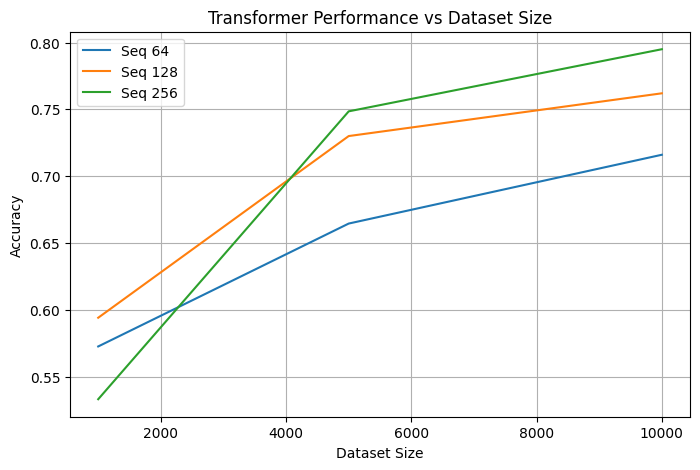

In [39]:
sizes = [1000,5000,10000]

trans_64 = [0.5725,0.6645,0.7160]
trans_128 = [0.5940,0.7300,0.7620]
trans_256 = [0.5330,0.7485,0.7950]

plt.figure(figsize=(8,5))

plt.plot(sizes,trans_64,label="Seq 64")
plt.plot(sizes,trans_128,label="Seq 128")
plt.plot(sizes,trans_256,label="Seq 256")

plt.xlabel("Dataset Size")
plt.ylabel("Accuracy")
plt.title("Transformer Performance vs Dataset Size")

plt.legend()
plt.grid()

plt.show()

🧠 Goal of This Experiment

Compare how long each model takes to make predictions.

Metrics:

Latency (seconds)
Throughput (samples/second)
Accuracy

Models tested:

LSTM
GRU
Transformer

⚙️ Step 1 — Load a Test Batch

We only measure inference, so we use the test loader.                              This gives a representative batch.

In [40]:
sample_batch = next(iter(test_loader))
input_ids = sample_batch["input_ids"].to(device)

⚙️ Step 2 — Latency Measurement Function

In [41]:
import time

def measure_latency(model, test_loader):

    model.eval()
    model.to(device)

    start = time.time()

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(device)

            outputs = model(input_ids)

    end = time.time()

    latency = end - start

    return latency

⚙️ Step 3 — Train Final Models (Best Setting)

Use the best configuration from experiments:

dataset_size = 10000
sequence_length = 256

Train each model once.

In [42]:
lstm_model = LSTMClassifier()
train_and_eval(lstm_model, train_loader, test_loader)

gru_model = GRUClassifier()
train_and_eval(gru_model, train_loader, test_loader)

trans_model = TransformerClassifier()
train_and_eval(trans_model, train_loader, test_loader)

/tmp/ipykernel_254/2696057220.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


0.8105

⚙️ Step 4 — Measure Latency

In [43]:
lstm_time = measure_latency(lstm_model, test_loader)
gru_time = measure_latency(gru_model, test_loader)
trans_time = measure_latency(trans_model, test_loader)

print("LSTM Latency:", lstm_time)
print("GRU Latency:", gru_time)
print("Transformer Latency:", trans_time)

LSTM Latency: 0.6452803611755371
GRU Latency: 0.31009697914123535
Transformer Latency: 0.5523717403411865


⚙️ Step 5 — Calculate Throughput

Throughput = samples processed per second.

In [44]:
num_samples = len(test_loader.dataset)

lstm_throughput = num_samples / lstm_time
gru_throughput = num_samples / gru_time
trans_throughput = num_samples / trans_time

print("LSTM Throughput:", lstm_throughput)
print("GRU Throughput:", gru_throughput)
print("Transformer Throughput:", trans_throughput)

LSTM Throughput: 3099.4279701252763
GRU Throughput: 6449.5952380403205
Transformer Throughput: 3620.7500383068996


📊 Plot Speed vs Accuracy

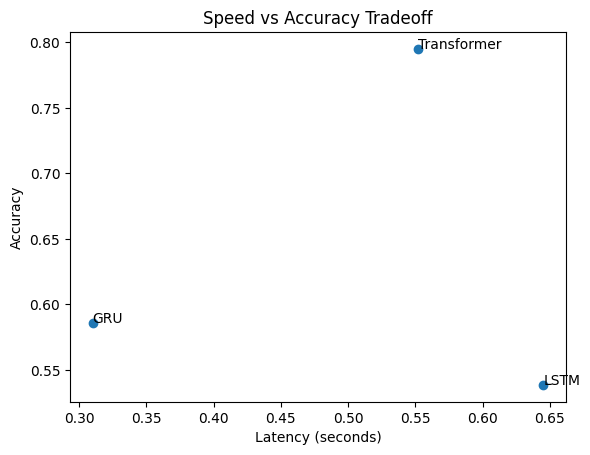

In [45]:
import matplotlib.pyplot as plt

models = ["LSTM","GRU","Transformer"]

accuracy = [0.5385,0.5860,0.7950]
latency = [lstm_time,gru_time,trans_time]

plt.scatter(latency,accuracy)

for i,model in enumerate(models):
    plt.text(latency[i],accuracy[i],model)

plt.xlabel("Latency (seconds)")
plt.ylabel("Accuracy")

plt.title("Speed vs Accuracy Tradeoff")

plt.show()